# 06 - Radar, eventos severos e ablation final

**Objetivo desta versao:** responder uma pergunta especifica antes de abrir 2025:

> **O radar melhora apenas o erro medio, ou tambem ajuda a detectar as grandes subidas?**

Este notebook compara **sem radar x com radar** em duas tarefas distintas:

1. **regressao:** quantos centimetros o nivel mudara em 2 h;
2. **alerta:** probabilidade de uma subida de pelo menos **1 m em 2 h**.

O limiar probabilistico do alerta e escolhido em **2023**. A comparacao decisiva e feita em **2024**. O periodo de 2025 continua intocado.

### Principais saidas novas
- `radar_regression_comparison_2024.csv/html`
- `radar_regression_alerts_2024.csv/html`
- `radar_classifier_comparison_2024.csv/html`
- `radar_episode_detection_2024.csv/html`
- `predictions/radar_ablation_2024_120min.csv`
- `reports/html/relatorio_radar_2024.html`
- `reports/pdf/relatorio_radar_2024.pdf`
- `reports/dashboards/dashboard_radar_2024.html`
- modelos de regressao/classificacao com radar em `models/`

In [35]:
from pathlib import Path
import re
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"
REPORTS = OUTPUTS / "reports"
REPORT_HTML = REPORTS / "html"
REPORT_PDF = REPORTS / "pdf"
REPORT_DASHBOARDS = REPORTS / "dashboards"

for p in [
    INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS,
    REPORT_HTML, REPORT_PDF, REPORT_DASHBOARDS,
]:
    p.mkdir(parents=True, exist_ok=True)


def find_dataset_root(raw_parent: Path) -> Path:
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia-o dentro de data/raw/ mantendo Data/SHP, "
        "Data/Radar e Data/Telemetric_Time_Series."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [36]:
def _fallback_path(path: Path) -> Path:
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")


def safe_to_csv(df, path, index=False):
    path = Path(path)
    try:
        df.to_csv(path, index=index)
        return path
    except PermissionError:
        alt = _fallback_path(path)
        df.to_csv(alt, index=index)
        print(f"AVISO: {path.name} estava bloqueado. Salvei em {alt.name}.")
        return alt


def safe_to_html(df, path, index=False):
    path = Path(path)
    try:
        df.to_html(path, index=index)
        return path
    except PermissionError:
        alt = _fallback_path(path)
        df.to_html(alt, index=index)
        print(f"AVISO: {path.name} estava bloqueado. Salvei em {alt.name}.")
        return alt


def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = safe_to_csv(z, TABLES / f"{stem}.csv", index=False)
    html_path = safe_to_html(z, TABLES / f"{stem}.html", index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando somente {min(preview_rows, len(z))} linhas."
    ))
    display(z.head(preview_rows))
    return z


def save_figure(fig, stem, dpi=220):
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def fbeta(precision, recall, beta=2.0):
    if np.isnan(precision) or np.isnan(recall):
        return np.nan
    den = beta**2 * precision + recall
    return (1 + beta**2) * precision * recall / den if den > 0 else 0.0

## 1. Leitura e consolidacao do radar

A base tem **um radar** e centenas de celulas espaciais. Primeiro construimos resumos causais por timestamp. Timestamps repetidos sao consolidados **antes** dos `rolling`, evitando o erro `cannot reindex on an axis with duplicate labels`.

In [37]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    mean_absolute_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
)

RADAR_PRE = RADAR / "radar_20150401_to_20250329_0000.csv"
RADAR_FAIL = RADAR / "radar_failure_series_2015-04-01_to_2025-03-29.csv"

assert RADAR_PRE.exists(), RADAR_PRE
print("Radar:", RADAR_PRE.name)
print("Serie de status/falhas encontrada:", RADAR_FAIL.exists())

Radar: radar_20150401_to_20250329_0000.csv
Serie de status/falhas encontrada: True


In [38]:
header = pd.read_csv(RADAR_PRE, nrows=0).columns.tolist()
time_col = header[0]
cell_cols = header[1:]

radar_meta = pd.DataFrame({
    "item": ["coluna_temporal", "celulas_radar", "total_colunas"],
    "valor": [time_col, len(cell_cols), len(header)],
})
display(radar_meta)
assert len(cell_cols) == 434, f"Esperadas 434 celulas; encontradas {len(cell_cols)}."

,item,valor
0,coluna_temporal,datahora
1,celulas_radar,434
2,total_colunas,435


In [39]:
parts = []
for i, chunk in enumerate(pd.read_csv(RADAR_PRE, chunksize=10_000)):
    if i % 10 == 0:
        print("Processando bloco", i + 1)

    chunk[time_col] = pd.to_datetime(chunk[time_col], format="mixed", errors="coerce")
    values = chunk[cell_cols].apply(pd.to_numeric, errors="coerce")

    out = pd.DataFrame({
        "time": chunk[time_col],
        "radar_mean": values.mean(axis=1),
        "radar_max": values.max(axis=1),
        "radar_p75": values.quantile(0.75, axis=1),
        "radar_p90": values.quantile(0.90, axis=1),
        "radar_p95": values.quantile(0.95, axis=1),
        "radar_wet_fraction": (values > 0.2).mean(axis=1),
        "radar_cells_available": values.notna().sum(axis=1),
    })
    parts.append(out)

radar_summary = pd.concat(parts, ignore_index=True)
del parts

radar_summary = radar_summary.dropna(subset=["time"])
radar_summary = radar_summary.groupby("time").mean(numeric_only=True).sort_index()
assert radar_summary.index.is_unique

summary = radar_summary.describe().T.reset_index(names="variavel")
save_table(summary, "radar_summary_statistics_v5", preview_rows=20)

Processando bloco 1
Processando bloco 11
Processando bloco 21
Processando bloco 31
Processando bloco 41
Processando bloco 51


**Tabela completa salva em:**  
- `outputs\tables\radar_summary_statistics_v5.csv`  
- `outputs\tables\radar_summary_statistics_v5.html`  
Mostrando somente 7 linhas.

,variavel,count,mean,std,min,25%,50%,75%,max
0,radar_mean,525571.0,0.026627,0.176614,0.0,0.0,0.0,0.0,8.880204
1,radar_max,525571.0,0.217855,1.212690,0.0,0.0,0.0,0.0,75.520338
2,radar_p75,525571.0,0.031926,0.247688,0.0,0.0,0.0,0.0,13.765429
3,radar_p90,525571.0,0.064852,0.461402,0.0,0.0,0.0,0.0,19.680236
4,radar_p95,525571.0,0.093364,0.624273,0.0,0.0,0.0,0.0,23.545844
5,radar_wet_fraction,525571.0,0.024422,0.122558,0.0,0.0,0.0,0.0,1.000000
6,radar_cells_available,525571.0,434.000000,0.000000,434.0,434.0,434.0,434.0,434.000000


,variavel,count,mean,std,min,25%,50%,75%,max
0,radar_mean,525571.0,0.026627,0.176614,0.0,0.0,0.0,0.0,8.880204
1,radar_max,525571.0,0.217855,1.212690,0.0,0.0,0.0,0.0,75.520338
2,radar_p75,525571.0,0.031926,0.247688,0.0,0.0,0.0,0.0,13.765429
3,radar_p90,525571.0,0.064852,0.461402,0.0,0.0,0.0,0.0,19.680236
4,radar_p95,525571.0,0.093364,0.624273,0.0,0.0,0.0,0.0,23.545844
5,radar_wet_fraction,525571.0,0.024422,0.122558,0.0,0.0,0.0,0.0,1.000000
6,radar_cells_available,525571.0,434.000000,0.000000,434.0,434.0,434.0,434.0,434.000000


In [40]:
if RADAR_FAIL.exists():
    fail = pd.read_csv(RADAR_FAIL)
    time_fail_col = "datahora" if "datahora" in fail.columns else fail.columns[0]
    fail[time_fail_col] = pd.to_datetime(
        fail[time_fail_col], format="mixed", dayfirst=True, errors="coerce"
    )
    fail = fail.dropna(subset=[time_fail_col]).set_index(time_fail_col).sort_index()

    if "present" in fail.columns:
        fail["present"] = pd.to_numeric(fail["present"], errors="coerce")
        if fail.index.has_duplicates:
            print("Status do radar possui timestamps repetidos; consolidando antes do join.")
        fail_unique = fail[["present"]].groupby(level=0).max()
        fail_unique = fail_unique.rename(columns={"present": "radar_present_flag"})
        radar_summary = radar_summary.join(fail_unique, how="left")

if radar_summary.index.has_duplicates:
    radar_summary = radar_summary.groupby(level=0).mean(numeric_only=True).sort_index()

assert radar_summary.index.is_unique
print("Indice unico apos status:", radar_summary.index.is_unique)

Status do radar possui timestamps repetidos; consolidando antes do join.
Indice unico apos status: True


In [41]:
radar_base_cols = [
    "radar_mean", "radar_max", "radar_p75", "radar_p90", "radar_p95",
    "radar_wet_fraction",
]

for col in radar_base_cols:
    for w, label in [(6, "1h"), (18, "3h"), (36, "6h")]:
        rolling = radar_summary[col].rolling(w, min_periods=max(1, int(0.8*w)))
        radar_summary[f"{col}_mean_{label}"] = rolling.mean()
        radar_summary[f"{col}_sum_{label}"] = rolling.sum()

radar_path = PROCESSED / "radar_features_basic.parquet"
radar_summary.to_parquet(radar_path)
print("Salvo:", radar_path.relative_to(ROOT))

Salvo: data\processed\radar_features_basic.parquet


## 2. Juncao com as 166 features causais

A juncao abaixo inclui uma protecao extra para arquivos `parquet` antigos que eventualmente tenham sido criados com indice duplicado.

In [42]:
x = pd.read_parquet(PROCESSED / "features_causal.parquet").sort_index()
radar_features = pd.read_parquet(PROCESSED / "radar_features_basic.parquet").sort_index()

if radar_features.index.has_duplicates:
    n_dup = int(radar_features.index.duplicated(keep=False).sum())
    print(f"Parquet do radar tem {n_dup} linhas em timestamps repetidos; consolidando.")
    radar_features = radar_features.groupby(level=0).mean(numeric_only=True).sort_index()

assert radar_features.index.is_unique
radar_features = radar_features.reindex(x.index)

x_radar = x.join(radar_features, how="left")
x_radar.to_parquet(PROCESSED / "features_causal_radar.parquet")

radar_cov = pd.DataFrame({
    "feature": radar_features.columns,
    "coverage_pct": [100 * radar_features[c].notna().mean() for c in radar_features.columns],
})
save_table(radar_cov, "radar_feature_coverage_v5", preview_rows=25)

**Tabela completa salva em:**  
- `outputs\tables\radar_feature_coverage_v5.csv`  
- `outputs\tables\radar_feature_coverage_v5.html`  
Mostrando somente 25 linhas.

,feature,coverage_pct
0,radar_mean,99.967094
1,radar_max,99.967094
2,radar_p75,99.967094
3,radar_p90,99.967094
4,radar_p95,99.967094
5,radar_wet_fraction,99.967094
6,radar_cells_available,99.967094
7,radar_present_flag,98.486906
8,radar_mean_mean_1h,99.966524
9,radar_mean_sum_1h,99.966524


,feature,coverage_pct
0,radar_mean,99.967094
1,radar_max,99.967094
2,radar_p75,99.967094
3,radar_p90,99.967094
4,radar_p95,99.967094
5,radar_wet_fraction,99.967094
6,radar_cells_available,99.967094
7,radar_present_flag,98.486906
8,radar_mean_mean_1h,99.966524
9,radar_mean_sum_1h,99.966524


## 3. Regressao: XGBoost sem radar x XGBoost com radar

Usamos o mesmo alvo de 2 h. O modelo **sem radar** e o XGBoost ja treinado no notebook 04. O modelo **com radar** usa os mesmos hiperparametros e escolhe o numero efetivo de arvores usando 2023.

A comparacao final desta etapa e em **2024**.

In [43]:
HORIZON = 120
TARGET = "target_delta_120m"

base_cols = [c for c in x.columns if c != "split" and not c.startswith("target_")]
radar_cols = list(radar_features.columns)
all_with_radar = base_cols + radar_cols


def get_split(df, split_name):
    z = df[df["split"] == split_name].copy()
    z = z[z["stage_now"].notna() & z[TARGET].notna()]
    return z

train_base = get_split(x, "train")
valid_base = get_split(x, "validation")
test_base = get_split(x, "test_2024")

train_radar = get_split(x_radar, "train")
valid_radar = get_split(x_radar, "validation")
test_radar = get_split(x_radar, "test_2024")

assert train_base.index.equals(train_radar.index)
assert valid_base.index.equals(valid_radar.index)
assert test_base.index.equals(test_radar.index)

base_reg = XGBRegressor()
base_model_path = MODELS / "xgb_dev_120m.json"
assert base_model_path.exists(), "Rode o notebook 04 primeiro."
base_reg.load_model(base_model_path)

radar_reg = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_estimators=1000,
    learning_rate=0.035,
    max_depth=6,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.80,
    reg_lambda=5.0,
    max_bin=128,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=60,
)
radar_reg.fit(
    train_radar[all_with_radar], train_radar[TARGET],
    eval_set=[(valid_radar[all_with_radar], valid_radar[TARGET])],
    verbose=False,
)
radar_reg.save_model(MODELS / "xgb_radar_dev_120m.json")

pred_valid_base = base_reg.predict(valid_base[base_cols])
pred_valid_radar = radar_reg.predict(valid_radar[all_with_radar])
pred_test_base = base_reg.predict(test_base[base_cols])
pred_test_radar = radar_reg.predict(test_radar[all_with_radar])

In [44]:
def regression_row(period, name, y, pred):
    y = np.asarray(y); pred = np.asarray(pred)
    e_cm = 100 * (pred - y)
    ae = np.abs(e_cm)
    return {
        "period": period,
        "model": name,
        "MAE_cm": ae.mean(),
        "RMSE_cm": np.sqrt(np.mean(e_cm**2)),
        "bias_cm": e_cm.mean(),
        "max_abs_error_cm": ae.max(),
        "within_20cm_pct": 100*np.mean(ae <= 20),
        "within_50cm_pct": 100*np.mean(ae <= 50),
    }

reg_rows = [
    regression_row("validation_2023", "sem_radar", valid_base[TARGET], pred_valid_base),
    regression_row("validation_2023", "com_radar", valid_radar[TARGET], pred_valid_radar),
    regression_row("test_2024", "sem_radar", test_base[TARGET], pred_test_base),
    regression_row("test_2024", "com_radar", test_radar[TARGET], pred_test_radar),
]
reg_compare = pd.DataFrame(reg_rows)

base_rmse_2024 = reg_compare.query("period == 'test_2024' and model == 'sem_radar'")["RMSE_cm"].iloc[0]
radar_rmse_2024 = reg_compare.query("period == 'test_2024' and model == 'com_radar'")["RMSE_cm"].iloc[0]
reg_compare["rmse_gain_vs_base_pct"] = np.where(
    reg_compare["period"].eq("test_2024") & reg_compare["model"].eq("com_radar"),
    100 * (base_rmse_2024 - radar_rmse_2024) / base_rmse_2024,
    np.nan,
)
save_table(reg_compare, "radar_regression_comparison_2024", preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\radar_regression_comparison_2024.csv`  
- `outputs\tables\radar_regression_comparison_2024.html`  
Mostrando somente 4 linhas.

,period,model,MAE_cm,RMSE_cm,bias_cm,max_abs_error_cm,within_20cm_pct,within_50cm_pct,rmse_gain_vs_base_pct
0,validation_2023,sem_radar,7.645297,25.283504,0.189440,607.570801,94.197603,97.651204,NaN
1,validation_2023,com_radar,7.782555,24.758556,0.473010,580.790161,93.738718,97.629456,NaN
2,test_2024,sem_radar,6.174969,21.390652,-0.283926,531.682800,95.380263,98.109020,NaN
3,test_2024,com_radar,6.093930,20.299667,-0.108189,493.409576,95.160483,98.211294,5.100286


,period,model,MAE_cm,RMSE_cm,bias_cm,max_abs_error_cm,within_20cm_pct,within_50cm_pct,rmse_gain_vs_base_pct
0,validation_2023,sem_radar,7.645297,25.283504,0.189440,607.570801,94.197603,97.651204,NaN
1,validation_2023,com_radar,7.782555,24.758556,0.473010,580.790161,93.738718,97.629456,NaN
2,test_2024,sem_radar,6.174969,21.390652,-0.283926,531.682800,95.380263,98.109020,NaN
3,test_2024,com_radar,6.093930,20.299667,-0.108189,493.409576,95.160483,98.211294,5.100286


## 4. O radar ajuda justamente nas subidas grandes?

Primeiro usamos as **previsoes continuas** como alerta: se o regressor prever subida acima do limiar, consideramos que houve alerta. Isso permite medir 0,5 m, 1 m, 2 m e 3 m sem treinar quatro classificadores diferentes.

In [45]:
def threshold_metrics(y, pred, threshold):
    y = np.asarray(y); pred = np.asarray(pred)
    real = y >= threshold
    alert = pred >= threshold
    tp = int(np.sum(real & alert))
    fn = int(np.sum(real & ~alert))
    fp = int(np.sum(~real & alert))
    precision = tp/(tp+fp) if (tp+fp) else np.nan
    recall = tp/(tp+fn) if (tp+fn) else np.nan
    return {
        "threshold_m": threshold,
        "real_events": int(real.sum()),
        "alerts": int(alert.sum()),
        "detected": tp,
        "missed": fn,
        "false_alerts": fp,
        "precision_pct": 100*precision if precision == precision else np.nan,
        "recall_pct": 100*recall if recall == recall else np.nan,
        "F2": fbeta(precision, recall, beta=2.0),
    }

reg_alert_rows = []
for th in [0.5, 1.0, 2.0, 3.0]:
    for name, pred in [("sem_radar", pred_test_base), ("com_radar", pred_test_radar)]:
        row = threshold_metrics(test_base[TARGET], pred, th)
        row["model"] = name
        reg_alert_rows.append(row)

reg_alerts = pd.DataFrame(reg_alert_rows)
save_table(reg_alerts, "radar_regression_alerts_2024", preview_rows=20)

**Tabela completa salva em:**  
- `outputs\tables\radar_regression_alerts_2024.csv`  
- `outputs\tables\radar_regression_alerts_2024.html`  
Mostrando somente 8 linhas.

,threshold_m,real_events,alerts,detected,missed,false_alerts,precision_pct,recall_pct,F2,model
0,0.5,1040,795,602,438,193,75.723270,57.884615,0.607467,sem_radar
1,0.5,1040,917,660,380,257,71.973828,63.461538,0.649990,com_radar
2,1.0,639,401,302,337,99,75.311721,47.261346,0.510653,sem_radar
3,1.0,639,406,320,319,86,78.817734,50.078247,0.540176,com_radar
4,2.0,313,124,96,217,28,77.419355,30.670927,0.348837,sem_radar
5,2.0,313,137,107,206,30,78.102190,34.185304,0.385169,com_radar
6,3.0,115,24,13,102,11,54.166667,11.304348,0.134298,sem_radar
7,3.0,115,35,17,98,18,48.571429,14.782609,0.171717,com_radar


,threshold_m,real_events,alerts,detected,missed,false_alerts,precision_pct,recall_pct,F2,model
0,0.5,1040,795,602,438,193,75.723270,57.884615,0.607467,sem_radar
1,0.5,1040,917,660,380,257,71.973828,63.461538,0.649990,com_radar
2,1.0,639,401,302,337,99,75.311721,47.261346,0.510653,sem_radar
3,1.0,639,406,320,319,86,78.817734,50.078247,0.540176,com_radar
4,2.0,313,124,96,217,28,77.419355,30.670927,0.348837,sem_radar
5,2.0,313,137,107,206,30,78.102190,34.185304,0.385169,com_radar
6,3.0,115,24,13,102,11,54.166667,11.304348,0.134298,sem_radar
7,3.0,115,35,17,98,18,48.571429,14.782609,0.171717,com_radar


## 5. Classificador de alerta >= 1 m em 2 h

Agora treinamos uma tarefa separada: **ha ou nao ha uma subida de pelo menos 1 m nas proximas 2 h?**

O limiar de probabilidade nao e escolhido em 2024: ele e escolhido em **2023**, maximizando o **F2**, que da mais peso ao recall do que a precision.

In [46]:
EVENT_THRESHOLD = 1.0
BETA = 2.0


def train_event_classifier(train_df, valid_df, cols, name):
    y_train = (train_df[TARGET] >= EVENT_THRESHOLD).astype(int)
    y_valid = (valid_df[TARGET] >= EVENT_THRESHOLD).astype(int)
    n_pos = int(y_train.sum())
    n_neg = int(len(y_train) - n_pos)

    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_estimators=600,
        learning_rate=0.035,
        max_depth=6,
        min_child_weight=10,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_lambda=5.0,
        scale_pos_weight=n_neg/max(n_pos, 1),
        random_state=42,
        n_jobs=-1,
    )
    clf.fit(train_df[cols], y_train)
    p = clf.predict_proba(valid_df[cols])[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_valid, p)
    precision = precision[:-1]
    recall = recall[:-1]
    f2 = (1+BETA**2)*precision*recall/(BETA**2*precision + recall + 1e-12)
    best_i = int(np.nanargmax(f2))
    threshold = float(thresholds[best_i])

    return clf, threshold, {
        "model": name,
        "probability_threshold": threshold,
        "validation_precision_pct": 100*precision[best_i],
        "validation_recall_pct": 100*recall[best_i],
        "validation_F2": float(f2[best_i]),
        "train_positive_events": n_pos,
    }

base_clf, base_prob_threshold, base_clf_valid = train_event_classifier(
    train_base, valid_base, base_cols, "classificador_sem_radar"
)
radar_clf, radar_prob_threshold, radar_clf_valid = train_event_classifier(
    train_radar, valid_radar, all_with_radar, "classificador_com_radar"
)

base_clf.save_model(MODELS / "event_classifier_base_120m.json")
radar_clf.save_model(MODELS / "event_classifier_radar_120m.json")

save_table(pd.DataFrame([base_clf_valid, radar_clf_valid]), "radar_classifier_validation", preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\radar_classifier_validation.csv`  
- `outputs\tables\radar_classifier_validation.html`  
Mostrando somente 2 linhas.

,model,probability_threshold,validation_precision_pct,validation_recall_pct,validation_F2,train_positive_events
0,classificador_sem_radar,0.578411,55.150555,74.919268,0.699076,6907
1,classificador_com_radar,0.598564,48.952514,75.457481,0.680847,6907


,model,probability_threshold,validation_precision_pct,validation_recall_pct,validation_F2,train_positive_events
0,classificador_sem_radar,0.578411,55.150555,74.919268,0.699076,6907
1,classificador_com_radar,0.598564,48.952514,75.457481,0.680847,6907


In [47]:
def classifier_test_row(name, y_true, probabilities, probability_threshold):
    real = np.asarray(y_true) >= EVENT_THRESHOLD
    alert = np.asarray(probabilities) >= probability_threshold
    tp = int(np.sum(real & alert)); fn = int(np.sum(real & ~alert)); fp = int(np.sum(~real & alert))
    precision = tp/(tp+fp) if tp+fp else np.nan
    recall = tp/(tp+fn) if tp+fn else np.nan
    f1 = 2*precision*recall/(precision+recall) if precision == precision and recall == recall and precision+recall > 0 else np.nan
    return {
        "model": name,
        "event_definition": ">= 1 m em 2 h",
        "probability_threshold_chosen_on_2023": probability_threshold,
        "real_events_2024": int(real.sum()),
        "alerts_2024": int(alert.sum()),
        "detected_2024": tp,
        "missed_2024": fn,
        "false_alerts_2024": fp,
        "precision_pct": 100*precision if precision == precision else np.nan,
        "recall_pct": 100*recall if recall == recall else np.nan,
        "F1": f1,
        "F2": fbeta(precision, recall, beta=2.0),
    }

p_test_base = base_clf.predict_proba(test_base[base_cols])[:, 1]
p_test_radar = radar_clf.predict_proba(test_radar[all_with_radar])[:, 1]

classifier_compare = pd.DataFrame([
    classifier_test_row("classificador_sem_radar", test_base[TARGET], p_test_base, base_prob_threshold),
    classifier_test_row("classificador_com_radar", test_radar[TARGET], p_test_radar, radar_prob_threshold),
])
save_table(classifier_compare, "radar_classifier_comparison_2024", preview_rows=10)

threshold_payload = {
    "event_threshold_m": EVENT_THRESHOLD,
    "base_probability_threshold": base_prob_threshold,
    "radar_probability_threshold": radar_prob_threshold,
    "selection_metric": "F2 on validation_2023",
}
(MODELS / "radar_classifier_thresholds.json").write_text(
    json.dumps(threshold_payload, indent=2), encoding="utf-8"
)

**Tabela completa salva em:**  
- `outputs\tables\radar_classifier_comparison_2024.csv`  
- `outputs\tables\radar_classifier_comparison_2024.html`  
Mostrando somente 2 linhas.

,model,event_definition,probability_threshold_chosen_on_2023,real_events_2024,alerts_2024,detected_2024,missed_2024,false_alerts_2024,precision_pct,recall_pct,F1,F2
0,classificador_sem_radar,>= 1 m em 2 h,0.578411,639,883,418,221,465,47.338618,65.414710,0.549277,0.607735
1,classificador_com_radar,>= 1 m em 2 h,0.598564,639,991,435,204,556,43.895055,68.075117,0.533742,0.613194


182

## 6. Episodios, nao apenas timestamps

Uma cheia pode gerar dezenas de linhas consecutivas de 10 minutos. Para uma leitura operacional, agrupamos linhas severas proximas em **episodios** e perguntamos se houve pelo menos um alerta no episodio.

In [48]:
pred_2024 = test_base[["stage_now", TARGET]].copy()
pred_2024["pred_sem_radar"] = pred_test_base
pred_2024["pred_com_radar"] = pred_test_radar
pred_2024["prob_sem_radar"] = p_test_base
pred_2024["prob_com_radar"] = p_test_radar
safe_to_csv(pred_2024.reset_index(names="prediction_time"), PREDICTIONS / "radar_ablation_2024_120min.csv", index=False)


def episode_summary(df, severity_threshold, gap_hours=6):
    severe = df[df[TARGET] >= severity_threshold].copy()
    if severe.empty:
        return pd.DataFrame()

    severe = severe.sort_index()
    starts = severe.index.to_series().diff().gt(pd.Timedelta(hours=gap_hours)).fillna(True)
    severe["episode_id"] = starts.cumsum().to_numpy()

    rows = []
    for ep_id, g in severe.groupby("episode_id"):
        peak_idx = g[TARGET].idxmax()
        peak_target_time = peak_idx + pd.Timedelta(minutes=HORIZON)

        row = {
            "severity_threshold_m": severity_threshold,
            "episode_id": int(ep_id),
            "start_prediction_time": g.index.min(),
            "end_prediction_time": g.index.max(),
            "peak_prediction_time": peak_idx,
            "peak_target_time": peak_target_time,
            "real_peak_delta_m": float(g.loc[peak_idx, TARGET]),
        }

        for label, pred_col in [("reg_sem_radar", "pred_sem_radar"), ("reg_com_radar", "pred_com_radar")]:
            hits = g[g[pred_col] >= severity_threshold]
            row[f"{label}_detected"] = bool(len(hits))
            row[f"{label}_first_alert_time"] = hits.index.min() if len(hits) else pd.NaT
            row[f"{label}_lead_to_peak_min"] = (
                (peak_target_time - hits.index.min()).total_seconds()/60 if len(hits) else np.nan
            )

        # Classificadores foram treinados para >=1 m. Avaliamos se alertaram tambem os episodios mais severos.
        for label, prob_col, prob_th in [
            ("clf_sem_radar", "prob_sem_radar", base_prob_threshold),
            ("clf_com_radar", "prob_com_radar", radar_prob_threshold),
        ]:
            hits = g[g[prob_col] >= prob_th]
            row[f"{label}_detected"] = bool(len(hits))
            row[f"{label}_first_alert_time"] = hits.index.min() if len(hits) else pd.NaT
            row[f"{label}_lead_to_peak_min"] = (
                (peak_target_time - hits.index.min()).total_seconds()/60 if len(hits) else np.nan
            )

        rows.append(row)

    return pd.DataFrame(rows)

episode_tables = []
for th in [1.0, 2.0, 3.0]:
    ep = episode_summary(pred_2024, th)
    if not ep.empty:
        episode_tables.append(ep)

episodes = pd.concat(episode_tables, ignore_index=True) if episode_tables else pd.DataFrame()
save_table(episodes, "radar_episode_detection_2024", preview_rows=25)

if not episodes.empty:
    summary_rows = []
    for th in [1.0, 2.0, 3.0]:
        z = episodes[episodes["severity_threshold_m"] == th]
        if z.empty:
            continue
        for method in ["reg_sem_radar", "reg_com_radar", "clf_sem_radar", "clf_com_radar"]:
            summary_rows.append({
                "severity_threshold_m": th,
                "method": method,
                "episodes": len(z),
                "detected_episodes": int(z[f"{method}_detected"].sum()),
                "episode_recall_pct": 100*z[f"{method}_detected"].mean(),
                "median_lead_to_peak_min": z.loc[z[f"{method}_detected"], f"{method}_lead_to_peak_min"].median(),
            })
    episode_summary_table = pd.DataFrame(summary_rows)
    save_table(episode_summary_table, "radar_episode_summary_2024", preview_rows=20)

**Tabela completa salva em:**  
- `outputs\tables\radar_episode_detection_2024.csv`  
- `outputs\tables\radar_episode_detection_2024.html`  
Mostrando somente 25 linhas.

,severity_threshold_m,episode_id,start_prediction_time,end_prediction_time,peak_prediction_time,peak_target_time,real_peak_delta_m,reg_sem_radar_detected,reg_sem_radar_first_alert_time,reg_sem_radar_lead_to_peak_min,reg_com_radar_detected,reg_com_radar_first_alert_time,reg_com_radar_lead_to_peak_min,clf_sem_radar_detected,clf_sem_radar_first_alert_time,clf_sem_radar_lead_to_peak_min,clf_com_radar_detected,clf_com_radar_first_alert_time,clf_com_radar_lead_to_peak_min
0,1.0,0,2024-01-08 17:10:00,2024-01-08 19:00:00,2024-01-08 17:40:00,2024-01-08 19:40:00,3.182007,True,2024-01-08 17:50:00,110.0,True,2024-01-08 18:00:00,100.0,True,2024-01-08 17:50:00,110.0,True,2024-01-08 18:20:00,80.0
1,1.0,1,2024-01-09 18:50:00,2024-01-09 20:00:00,2024-01-09 19:30:00,2024-01-09 21:30:00,2.088013,True,2024-01-09 19:40:00,110.0,True,2024-01-09 19:40:00,110.0,True,2024-01-09 19:10:00,140.0,True,2024-01-09 19:40:00,110.0
2,1.0,2,2024-01-10 19:20:00,2024-01-11 00:10:00,2024-01-10 20:50:00,2024-01-10 22:50:00,1.912964,True,2024-01-10 19:40:00,190.0,True,2024-01-10 19:50:00,180.0,True,2024-01-10 19:50:00,180.0,True,2024-01-10 20:00:00,170.0
3,1.0,3,2024-01-12 17:50:00,2024-01-12 23:30:00,2024-01-12 21:10:00,2024-01-12 23:10:00,3.760986,True,2024-01-12 18:00:00,310.0,True,2024-01-12 18:00:00,310.0,True,2024-01-12 17:50:00,320.0,True,2024-01-12 17:50:00,320.0
4,1.0,4,2024-01-31 17:30:00,2024-01-31 19:00:00,2024-01-31 18:10:00,2024-01-31 20:10:00,4.919006,True,2024-01-31 18:10:00,120.0,True,2024-01-31 17:40:00,150.0,True,2024-01-31 18:30:00,100.0,True,2024-01-31 18:30:00,100.0
5,1.0,5,2024-02-01 16:00:00,2024-02-01 17:30:00,2024-02-01 16:20:00,2024-02-01 18:20:00,2.356995,True,2024-02-01 17:10:00,70.0,True,2024-02-01 17:10:00,70.0,True,2024-02-01 17:00:00,80.0,True,2024-02-01 16:50:00,90.0
6,1.0,6,2024-02-02 15:30:00,2024-02-02 18:20:00,2024-02-02 17:00:00,2024-02-02 19:00:00,3.479980,True,2024-02-02 16:10:00,170.0,True,2024-02-02 16:10:00,170.0,True,2024-02-02 15:30:00,210.0,True,2024-02-02 15:30:00,210.0
7,1.0,7,2024-02-04 16:00:00,2024-02-04 18:10:00,2024-02-04 17:10:00,2024-02-04 19:10:00,3.268005,True,2024-02-04 17:10:00,120.0,True,2024-02-04 17:00:00,130.0,True,2024-02-04 16:00:00,190.0,True,2024-02-04 16:20:00,170.0
8,1.0,8,2024-02-13 23:50:00,2024-02-14 02:40:00,2024-02-14 01:20:00,2024-02-14 03:20:00,7.048950,True,2024-02-14 00:20:00,180.0,True,2024-02-14 00:40:00,160.0,True,2024-02-14 00:10:00,190.0,True,2024-02-13 23:50:00,210.0
9,1.0,9,2024-02-18 16:40:00,2024-02-18 18:50:00,2024-02-18 17:40:00,2024-02-18 19:40:00,4.745972,True,2024-02-18 18:00:00,100.0,True,2024-02-18 18:00:00,100.0,True,2024-02-18 18:00:00,100.0,True,2024-02-18 17:40:00,120.0


**Tabela completa salva em:**  
- `outputs\tables\radar_episode_summary_2024.csv`  
- `outputs\tables\radar_episode_summary_2024.html`  
Mostrando somente 12 linhas.

,severity_threshold_m,method,episodes,detected_episodes,episode_recall_pct,median_lead_to_peak_min
0,1.0,reg_sem_radar,48,43,89.583333,140.0
1,1.0,reg_com_radar,48,43,89.583333,150.0
2,1.0,clf_sem_radar,48,46,95.833333,170.0
3,1.0,clf_com_radar,48,44,91.666667,170.0
4,2.0,reg_sem_radar,35,23,65.714286,130.0
5,2.0,reg_com_radar,35,22,62.857143,140.0
6,2.0,clf_sem_radar,35,34,97.142857,140.0
7,2.0,clf_com_radar,35,33,94.285714,150.0
8,3.0,reg_sem_radar,18,5,27.777778,100.0
9,3.0,reg_com_radar,18,7,38.888889,120.0


## 7. Atrasos empiricos das estacoes a montante

Mantemos esta analise porque os lags encontrados podem virar features hidrologicas explicitas numa etapa posterior.

**Tabela completa salva em:**  
- `outputs\tables\upstream_lag_correlations.csv`  
- `outputs\tables\upstream_lag_correlations.html`  
Mostrando somente 25 linhas.

,station,lag_min,corr
42,143,50,0.138455
43,143,60,0.133609
41,143,40,0.131768
40,143,30,0.127294
39,143,20,0.120919
44,143,70,0.119827
38,143,10,0.113091
45,143,80,0.106691
37,143,0,0.100538
46,143,90,0.089659


**Figura salva em:** `outputs\figures\upstream_lag_correlations.png`

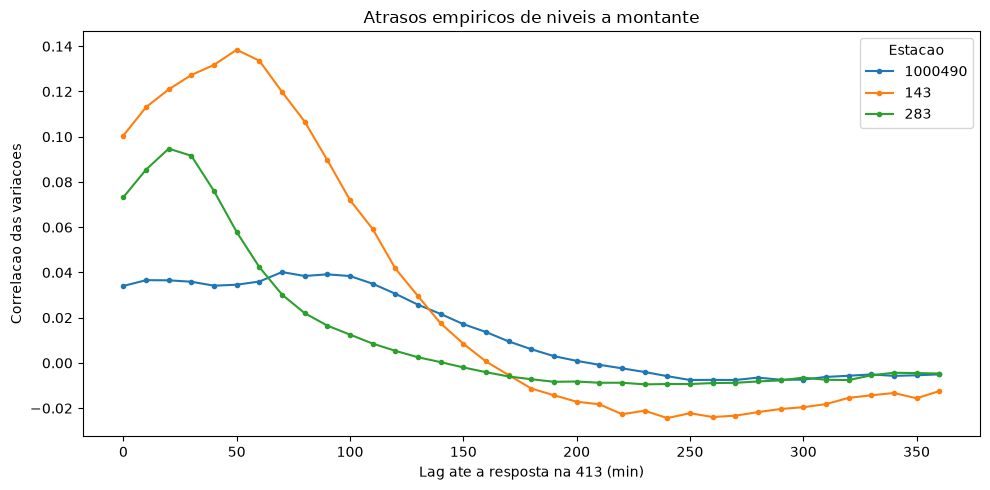

In [49]:
master = pd.read_parquet(PROCESSED / "master_base.parquet")
lag_rows = []
for sid in [1000490, 143, 283]:
    a = master[f"stage_{sid}"].diff()
    b = master["stage_413"].diff()
    for lag_steps in range(0, 37):
        lag_rows.append({
            "station": sid,
            "lag_min": lag_steps*10,
            "corr": a.corr(b.shift(-lag_steps)),
        })

lag_table = pd.DataFrame(lag_rows)
save_table(lag_table.sort_values(["station", "corr"], ascending=[True, False]), "upstream_lag_correlations", preview_rows=25)

fig, ax = plt.subplots(figsize=(10,5))
for sid in [1000490,143,283]:
    z = lag_table[lag_table["station"] == sid]
    ax.plot(z["lag_min"], z["corr"], marker="o", markersize=3, label=str(sid))
ax.set_xlabel("Lag ate a resposta na 413 (min)")
ax.set_ylabel("Correlacao das variacoes")
ax.set_title("Atrasos empiricos de niveis a montante")
ax.legend(title="Estacao")
plt.tight_layout()
save_figure(fig, "upstream_lag_correlations")
plt.show()

## 8. Relatorio visual do experimento de radar

O relatorio final coloca lado a lado erro global, deteccao de eventos e um exemplo do maior episodio de 2024.

**Figura salva em:** `outputs\figures\radar_v5_rmse_2024.png`

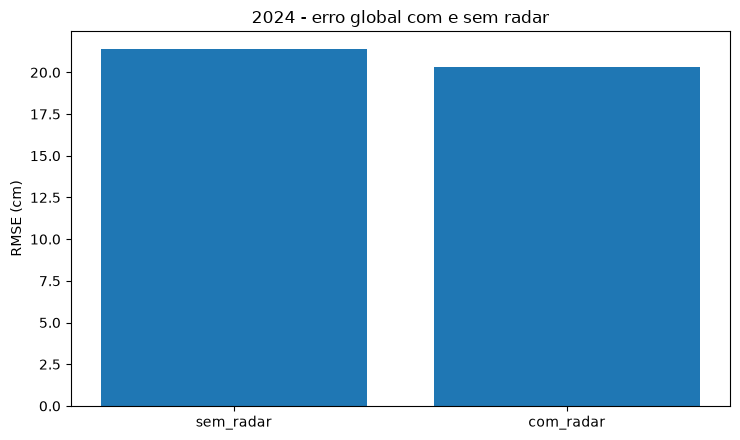

**Figura salva em:** `outputs\figures\radar_v5_classifier_2024.png`

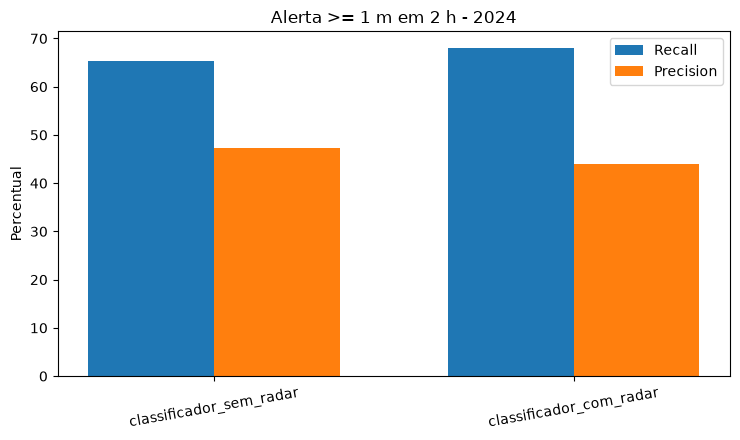

**Figura salva em:** `outputs\figures\radar_v5_regression_recall_2024.png`

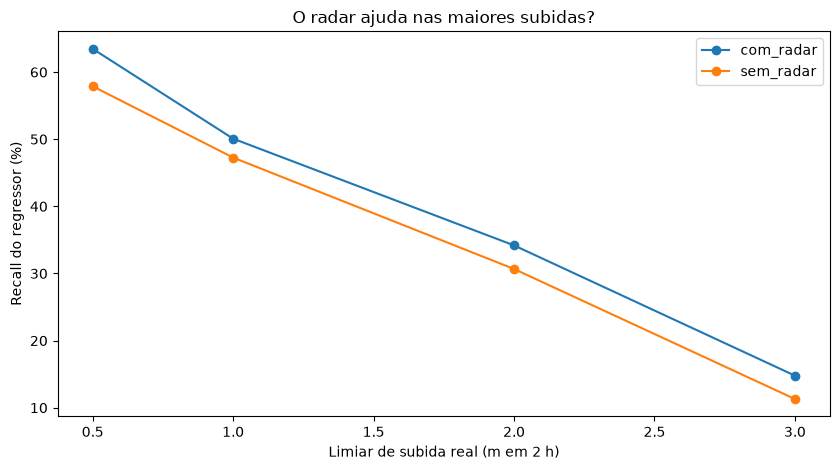

**Figura salva em:** `outputs\figures\radar_v5_peak_event_2024.png`

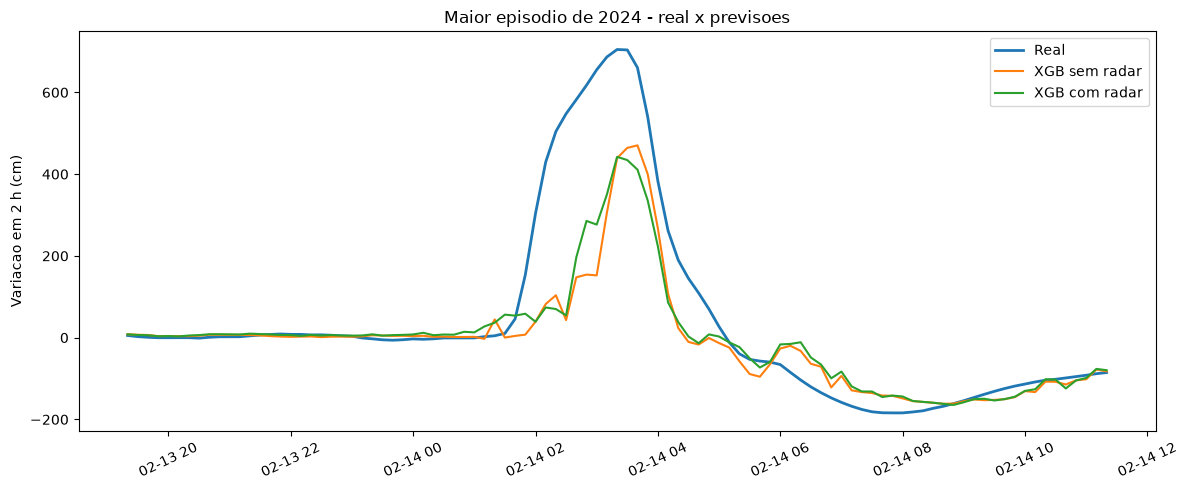

outputs\reports\html\relatorio_radar_2024.html
outputs\reports\pdf\relatorio_radar_2024.pdf
outputs\reports\dashboards\dashboard_radar_2024.html


In [50]:
from pathlib import Path
import base64
from matplotlib.backends.backend_pdf import PdfPages

try:
    import plotly.graph_objects as go
    import plotly.io as pio
except ImportError as exc:
    raise ImportError("Instale plotly: python -m pip install plotly") from exc

# Figuras estaticas.
test_reg = reg_compare[reg_compare["period"] == "test_2024"].copy()
fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.bar(test_reg["model"], test_reg["RMSE_cm"])
ax.set_ylabel("RMSE (cm)")
ax.set_title("2024 - erro global com e sem radar")
plt.tight_layout(); f_rmse = save_figure(fig, "radar_v5_rmse_2024"); plt.show()

fig, ax = plt.subplots(figsize=(7.5,4.5))
xx = np.arange(len(classifier_compare))
w = 0.35
ax.bar(xx-w/2, classifier_compare["recall_pct"], width=w, label="Recall")
ax.bar(xx+w/2, classifier_compare["precision_pct"], width=w, label="Precision")
ax.set_xticks(xx, classifier_compare["model"], rotation=10)
ax.set_ylabel("Percentual")
ax.set_title("Alerta >= 1 m em 2 h - 2024")
ax.legend()
plt.tight_layout(); f_clf = save_figure(fig, "radar_v5_classifier_2024"); plt.show()

fig, ax = plt.subplots(figsize=(8.5,4.8))
for name, g in reg_alerts.groupby("model"):
    ax.plot(g["threshold_m"], g["recall_pct"], marker="o", label=name)
ax.set_xlabel("Limiar de subida real (m em 2 h)")
ax.set_ylabel("Recall do regressor (%)")
ax.set_title("O radar ajuda nas maiores subidas?")
ax.legend()
plt.tight_layout(); f_reg_alert = save_figure(fig, "radar_v5_regression_recall_2024"); plt.show()

peak_idx = pred_2024[TARGET].idxmax()
z = pred_2024.loc[peak_idx-pd.Timedelta(hours=8):peak_idx+pd.Timedelta(hours=8)].copy()
z["target_time"] = z.index + pd.Timedelta(minutes=HORIZON)
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(z["target_time"], 100*z[TARGET], label="Real", linewidth=2)
ax.plot(z["target_time"], 100*z["pred_sem_radar"], label="XGB sem radar")
ax.plot(z["target_time"], 100*z["pred_com_radar"], label="XGB com radar")
ax.set_ylabel("Variacao em 2 h (cm)")
ax.set_title("Maior episodio de 2024 - real x previsoes")
ax.legend(); plt.xticks(rotation=25); plt.tight_layout()
f_peak = save_figure(fig, "radar_v5_peak_event_2024"); plt.show()


def uri(path):
    return "data:image/png;base64," + base64.b64encode(Path(path).read_bytes()).decode("ascii")

best_reg = test_reg.sort_values("RMSE_cm").iloc[0]
best_clf = classifier_compare.sort_values(["F2", "recall_pct"], ascending=False).iloc[0]

html = f'''<!doctype html><html lang="pt-br"><head><meta charset="utf-8"><title>Radar - 2024</title>
<style>body{{font-family:Arial;background:#f5f6f8;margin:0;color:#1f2731}}main{{max-width:1150px;margin:auto;padding:28px}}.panel{{background:white;border:1px solid #ddd;border-radius:12px;padding:18px;margin:16px 0;overflow:auto}}.cards{{display:grid;grid-template-columns:repeat(auto-fit,minmax(230px,1fr));gap:14px}}.card{{background:white;border:1px solid #ddd;border-radius:12px;padding:18px}}table{{width:100%;border-collapse:collapse;font-size:13px}}th{{background:#edf1f5}}th,td{{padding:8px;border-top:1px solid #e1e5ea;text-align:left}}img{{max-width:100%}}.note{{background:#fff7e8;border-left:5px solid #c99943;padding:14px}}</style></head><body><main>
<h1>O radar ajuda? - avaliacao em 2024</h1>
<div class="cards"><div class="card"><b>Melhor regressao</b><h2>{best_reg['model']}</h2>RMSE {best_reg['RMSE_cm']:.1f} cm</div><div class="card"><b>Melhor classificador >=1 m</b><h2>{best_clf['model']}</h2>Recall {best_clf['recall_pct']:.1f}% | Precision {best_clf['precision_pct']:.1f}%</div></div>
<div class="note">O radar so deve entrar na arquitetura final se o ganho se mantiver em 2024 e, de preferencia, melhorar a deteccao de eventos severos. 2025 nao foi usado aqui.</div>
<h2>Erro global</h2><div class="panel"><img src="{uri(f_rmse)}"></div><div class="panel">{test_reg.round(2).to_html(index=False,border=0)}</div>
<h2>Classificador de eventos</h2><div class="panel"><img src="{uri(f_clf)}"></div><div class="panel">{classifier_compare.round(3).to_html(index=False,border=0)}</div>
<h2>Recall das previsoes continuas por intensidade</h2><div class="panel"><img src="{uri(f_reg_alert)}"></div><div class="panel">{reg_alerts.round(3).to_html(index=False,border=0)}</div>
<h2>Maior episodio</h2><div class="panel"><img src="{uri(f_peak)}"></div>
<h2>Deteccao por episodio</h2><div class="panel">{episode_summary_table.round(2).to_html(index=False,border=0) if 'episode_summary_table' in globals() else 'Sem episodios para resumir.'}</div>
</main></body></html>'''
html_path = REPORT_HTML / "relatorio_radar_2024.html"; html_path.write_text(html, encoding="utf-8")

pdf_path = REPORT_PDF / "relatorio_radar_2024.pdf"
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27,11.69)); fig.text(0.08,0.92,"Radar - avaliacao em 2024",fontsize=20,weight="bold"); fig.text(0.08,0.83,f"Melhor regressao: {best_reg['model']} - RMSE {best_reg['RMSE_cm']:.1f} cm",fontsize=12); fig.text(0.08,0.77,f"Melhor alerta >=1 m: {best_clf['model']} - recall {best_clf['recall_pct']:.1f}%",fontsize=12); fig.text(0.08,0.66,"2025 permanece intocado. Este relatorio serve para decidir se o radar entra no modelo final.",fontsize=10,wrap=True); plt.axis("off"); pdf.savefig(fig); plt.close(fig)
    for title, path in [("RMSE",f_rmse),("Classificador",f_clf),("Recall por limiar",f_reg_alert),("Maior episodio",f_peak)]:
        img = plt.imread(path); fig,ax=plt.subplots(figsize=(11.69,8.27)); ax.imshow(img); ax.axis("off"); ax.set_title(title,fontsize=16); pdf.savefig(fig,bbox_inches="tight"); plt.close(fig)

# Dashboard interativo.
fig1 = go.Figure()
fig1.add_trace(go.Bar(x=test_reg["model"], y=test_reg["RMSE_cm"], name="RMSE"))
fig1.update_layout(title="RMSE em 2024", yaxis_title="cm")

fig2 = go.Figure()
for name,g in reg_alerts.groupby("model"):
    fig2.add_trace(go.Scatter(x=g["threshold_m"],y=g["recall_pct"],mode="lines+markers",name=name))
fig2.update_layout(title="Recall por limiar",xaxis_title="Limiar (m)",yaxis_title="Recall (%)")

fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=z["target_time"],y=100*z[TARGET],mode="lines",name="Real"))
fig3.add_trace(go.Scatter(x=z["target_time"],y=100*z["pred_sem_radar"],mode="lines",name="Sem radar"))
fig3.add_trace(go.Scatter(x=z["target_time"],y=100*z["pred_com_radar"],mode="lines",name="Com radar"))
fig3.update_layout(title="Maior episodio",yaxis_title="Variacao em 2 h (cm)")

p1=pio.to_html(fig1,full_html=False,include_plotlyjs="inline"); p2=pio.to_html(fig2,full_html=False,include_plotlyjs=False); p3=pio.to_html(fig3,full_html=False,include_plotlyjs=False)
dash=f'''<!doctype html><html><head><meta charset="utf-8"><title>Dashboard radar 2024</title><style>body{{font-family:Arial;background:#f5f6f8;margin:0}}main{{max-width:1200px;margin:auto;padding:24px}}.panel{{background:white;border:1px solid #ddd;border-radius:12px;padding:14px;margin:16px 0}}</style></head><body><main><h1>Dashboard - radar em 2024</h1><div class="panel">{p1}</div><div class="panel">{p2}</div><div class="panel">{p3}</div></main></body></html>'''
dash_path=REPORT_DASHBOARDS/"dashboard_radar_2024.html"; dash_path.write_text(dash,encoding="utf-8")

selection = {
    "regression_best_by_rmse_2024": str(best_reg["model"]),
    "regression_rmse_cm_2024": float(best_reg["RMSE_cm"]),
    "classifier_best_by_F2_2024": str(best_clf["model"]),
    "classifier_recall_pct_2024": float(best_clf["recall_pct"]),
    "classifier_precision_pct_2024": float(best_clf["precision_pct"]),
    "note": "2024 e development test; 2025 ainda nao foi aberto.",
}
(MODELS / "radar_selection_2024.json").write_text(json.dumps(selection,indent=2),encoding="utf-8")

print(html_path.relative_to(ROOT)); print(pdf_path.relative_to(ROOT)); print(dash_path.relative_to(ROOT))